# Notebook 05 — Khai phá Dữ liệu (Data Mining)
**Đề tài 7 — Nhóm 13 | 2025–2026**

---
## A. Khai phá Luật kết hợp (Association Rule Mining — Apriori)
Tìm các điều kiện canh tác (mưa + nhiệt độ + thuốc trừ sâu + loại cây) dẫn đến năng suất cao/thấp.

## B. Phân cụm Vùng trồng (K-Means Clustering)
Nhóm các quốc gia theo đặc điểm khí hậu và năng suất.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

PROC = Path("../data/processed")
OUT  = Path("../outputs/figures"); OUT.mkdir(parents=True, exist_ok=True)
RPTS = Path("../outputs/reports"); RPTS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROC / "crop_yield_processed.csv")
print(f"Dataset: {df.shape[0]:,} dòng")
df[["Area","Item","Year","hg/ha_yield","yield_cat","rain_cat","temp_cat","pest_cat"]].head(3)

Dataset: 28,242 dòng


,Area,Item,Year,hg/ha_yield,yield_cat,rain_cat,temp_cat,pest_cat
0,Albania,Maize,1990,36613.0,Medium,Wet,Cold,LowPest
1,Albania,Potatoes,1990,66667.0,Medium,Wet,Cold,LowPest
2,Albania,"Rice, paddy",1990,23333.0,Low,Wet,Cold,LowPest


## PHẦN A: Association Rule Mining (Apriori)

In [2]:
# Xây dựng transactions
transactions = []
for _, row in df.iterrows():
    t = [
        f"crop_{str(row['Item']).replace(', ','_').replace(' ','_')}",
        f"rain_{row['rain_cat']}",
        f"temp_{row['temp_cat']}",
        f"pest_{row['pest_cat']}",
        f"yield_{row['yield_cat']}",
    ]
    transactions.append(t)

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)

print(f"Transaction matrix: {df_te.shape[0]:,} dòng × {df_te.shape[1]} cột (one-hot)")
print(f"Các item: {te.columns_}")

Transaction matrix: 28,242 dòng × 22 cột (one-hot)
Các item: ['crop_Cassava', 'crop_Maize', 'crop_Plantains_and_others', 'crop_Potatoes', 'crop_Rice_paddy', 'crop_Sorghum', 'crop_Soybeans', 'crop_Sweet_potatoes', 'crop_Wheat', 'crop_Yams', 'pest_HighPest', 'pest_LowPest', 'pest_MedPest', 'rain_Dry', 'rain_Moderate', 'rain_Wet', 'temp_Cold', 'temp_Hot', 'temp_Temperate', 'yield_High', 'yield_Low', 'yield_Medium']


In [3]:
# Khai phá frequent itemsets
freq_sets = apriori(df_te, min_support=0.04, use_colnames=True, max_len=5)
freq_sets_sorted = freq_sets.sort_values("support", ascending=False)
print(f"Frequent itemsets (support ≥ 4%): {len(freq_sets)}")
print("\nTop 10 frequent itemsets:")
print(freq_sets_sorted.head(10).to_string(index=False))

Frequent itemsets (support ≥ 4%): 172

Top 10 frequent itemsets:
 support         itemsets
0.349090  (rain_Moderate)
0.344699   (pest_MedPest)
0.339990   (yield_Medium)
0.339069 (temp_Temperate)
0.333085       (rain_Dry)
0.331350      (temp_Cold)
0.330040   (pest_LowPest)
0.330005     (yield_High)
0.330005      (yield_Low)
0.329580       (temp_Hot)


In [4]:
# Sinh luật kết hợp
rules = association_rules(freq_sets, metric="confidence", min_threshold=0.45, num_itemsets=len(freq_sets))
rules = rules.sort_values("lift", ascending=False)
print(f"Tổng số luật sinh ra: {len(rules)}")

rules_high = rules[rules["consequents"].astype(str).str.contains("yield_High")]
rules_low  = rules[rules["consequents"].astype(str).str.contains("yield_Low")]
print(f"Luật → năng suất CAO  : {len(rules_high)}")
print(f"Luật → năng suất THẤP : {len(rules_low)}")

Tổng số luật sinh ra: 67
Luật → năng suất CAO  : 9
Luật → năng suất THẤP : 6


In [5]:
print("\n=== TOP 15 LUẬT → NĂNG SUẤT CAO ===")
for _, r in rules_high.head(15).iterrows():
    ant = " + ".join(sorted(list(r["antecedents"])))
    print(f"  [{ant}]")
    print(f"    → HIGH YIELD | sup={r['support']:.3f} | conf={r['confidence']:.3f} | lift={r['lift']:.3f}\n")

print("=== TOP 5 LUẬT → NĂNG SUẤT THẤP ===")
for _, r in rules_low.head(5).iterrows():
    ant = " + ".join(sorted(list(r["antecedents"])))
    print(f"  [{ant}] → LOW YIELD | conf={r['confidence']:.3f} | lift={r['lift']:.3f}")


=== TOP 15 LUẬT → NĂNG SUẤT CAO ===
  [crop_Potatoes + pest_HighPest]
    → HIGH YIELD | sup=0.043 | conf=1.000 | lift=3.030

  [crop_Potatoes + temp_Cold]
    → HIGH YIELD | sup=0.062 | conf=0.981 | lift=2.973

  [crop_Potatoes + pest_MedPest]
    → HIGH YIELD | sup=0.054 | conf=0.979 | lift=2.966

  [crop_Potatoes + rain_Dry]
    → HIGH YIELD | sup=0.057 | conf=0.964 | lift=2.922

  [crop_Potatoes]
    → HIGH YIELD | sup=0.140 | conf=0.928 | lift=2.811

  [crop_Potatoes + rain_Moderate]
    → HIGH YIELD | sup=0.047 | conf=0.914 | lift=2.770

  [crop_Potatoes + pest_LowPest]
    → HIGH YIELD | sup=0.044 | conf=0.817 | lift=2.475

  [crop_Cassava]
    → HIGH YIELD | sup=0.056 | conf=0.770 | lift=2.332

  [crop_Sweet_potatoes]
    → HIGH YIELD | sup=0.077 | conf=0.752 | lift=2.278

=== TOP 5 LUẬT → NĂNG SUẤT THẤP ===
  [crop_Soybeans] → LOW YIELD | conf=0.830 | lift=2.514
  [crop_Sorghum] → LOW YIELD | conf=0.722 | lift=2.187
  [pest_LowPest + temp_Temperate] → LOW YIELD | conf=0.515 |

In [6]:
# Lưu luật
def jsonify_rules(r):
    return {"antecedents": list(r["antecedents"]), "consequents": list(r["consequents"]),
            "support": round(r["support"],4), "confidence": round(r["confidence"],4), "lift": round(r["lift"],4)}

all_rules_out = [jsonify_rules(r) for _, r in rules.head(50).iterrows()]
with open(RPTS / "apriori_rules.json", "w") as f:
    json.dump({"total": len(rules), "rules_high_yield": len(rules_high),
               "rules_low_yield": len(rules_low), "top50": all_rules_out}, f, indent=2)
print(f"Saved: apriori_rules.json ({len(rules)} luật tổng cộng)")

Saved: apriori_rules.json (67 luật tổng cộng)


## PHẦN B: Phân cụm K-Means

In [7]:
# Chọn đặc trưng cho clustering
cluster_features = ["average_rain_fall_mm_per_year","avg_temp","pesticides_tonnes","hg/ha_yield"]
X_c = df[cluster_features].copy()
X_c["hg/ha_yield"] = X_c["hg/ha_yield"] / 1000  # scale down
X_scaled = StandardScaler().fit_transform(X_c)

# Elbow + Silhouette
inertias, sils = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lb = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, lb))

best_k = 2 + np.argmax(sils)
print(f"Kết quả Elbow + Silhouette:")
for k, s, inn in zip(K_range, sils, inertias):
    mark = " ← BEST" if k == best_k else ""
    print(f"  K={k}: Silhouette={s:.4f}, Inertia={inn:.1f}{mark}")

Kết quả Elbow + Silhouette:
  K=2: Silhouette=0.2486, Inertia=86511.5
  K=3: Silhouette=0.2859, Inertia=66955.3
  K=4: Silhouette=0.3154, Inertia=50096.7
  K=5: Silhouette=0.3347, Inertia=37660.6 ← BEST
  K=6: Silhouette=0.3000, Inertia=33262.2
  K=7: Silhouette=0.3226, Inertia=29769.3
  K=8: Silhouette=0.3305, Inertia=26332.3
  K=9: Silhouette=0.3225, Inertia=24114.1
  K=10: Silhouette=0.3346, Inertia=22130.9


In [8]:
import json as _json
import numpy as _np
from sklearn.cluster import KMeans

# ── Fit mô hình K tối ưu ─────────────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = km_final.fit_predict(X_scaled)
best_sil = sils[best_k - 2]
print(f"K tối ưu = {best_k}, Silhouette = {best_sil:.4f}")

# ── Profile từng cluster ──────────────────────────────────────────
print("\n=== PROFILE TỪNG CLUSTER ===")
cluster_profiles = []

for c in range(best_k):
    sub = df[df["cluster"] == c]
    top_crops = sub["Item"].value_counts().head(3).index.tolist()
    top_areas = sub["Area"].value_counts().head(3).index.tolist()

    profile = {
        "cluster":    int(c),
        "n":          int(len(sub)),
        "yield_mean": float(round(sub["hg/ha_yield"].mean(), 0)),
        "rain_mean":  float(round(sub["average_rain_fall_mm_per_year"].mean(), 0)),
        "temp_mean":  float(round(sub["avg_temp"].mean(), 2)),
        "pest_mean":  float(round(sub["pesticides_tonnes"].mean(), 2)),
        "top_crops":  [str(x) for x in top_crops],
        "top_areas":  [str(x) for x in top_areas],
    }
    cluster_profiles.append(profile)

    print(f"\nCluster {c} (n={len(sub):,}):")
    print(f"  Yield : {sub['hg/ha_yield'].mean():,.0f} hg/ha")
    print(f"  Rain  : {sub['average_rain_fall_mm_per_year'].mean():.0f} mm/yr")
    print(f"  Temp  : {sub['avg_temp'].mean():.1f} °C")
    print(f"  Top crops : {top_crops}")
    print(f"  Top areas : {top_areas}")

# ── Lưu kết quả ──────────────────────────────────────────────────
class _NpEnc(_json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, _np.integer): return int(obj)
        if isinstance(obj, _np.floating): return float(obj)
        if isinstance(obj, _np.ndarray):  return obj.tolist()
        return super().default(obj)

with open(RPTS / "cluster_summary.json", "w", encoding="utf-8") as f:
    _json.dump(
        {"k": int(best_k), "silhouette": float(best_sil), "clusters": cluster_profiles},
        f, indent=2, cls=_NpEnc, ensure_ascii=False
    )
print("\nSaved: cluster_summary.json")

K tối ưu = 5, Silhouette = 0.3347

=== PROFILE TỪNG CLUSTER ===

Cluster 0 (n=990):
  Yield : 84,080 hg/ha
  Rain  : 1761 mm/yr
  Temp  : 22.7 °C
  Top crops : ['Cassava', 'Maize', 'Potatoes']
  Top areas : ['Brazil']

Cluster 1 (n=3,968):
  Yield : 245,212 hg/ha
  Rain  : 929 mm/yr
  Temp  : 19.3 °C
  Top crops : ['Potatoes', 'Sweet potatoes', 'Cassava']
  Top areas : ['India', 'Japan', 'Mexico']

Cluster 2 (n=6,955):
  Yield : 51,119 hg/ha
  Rain  : 801 mm/yr
  Temp  : 12.4 °C
  Top crops : ['Wheat', 'Maize', 'Soybeans']
  Top areas : ['Japan', 'Canada', 'Australia']

Cluster 3 (n=5,845):
  Yield : 63,573 hg/ha
  Rain  : 2206 mm/yr
  Temp  : 24.5 °C
  Top crops : ['Maize', 'Rice, paddy', 'Cassava']
  Top areas : ['Brazil', 'Indonesia', 'Ecuador']

Cluster 4 (n=10,484):
  Yield : 36,524 hg/ha
  Rain  : 816 mm/yr
  Temp  : 24.0 °C
  Top crops : ['Maize', 'Sorghum', 'Wheat']
  Top areas : ['India', 'Pakistan', 'Mexico']

Saved: cluster_summary.json


## Visualisations Mining

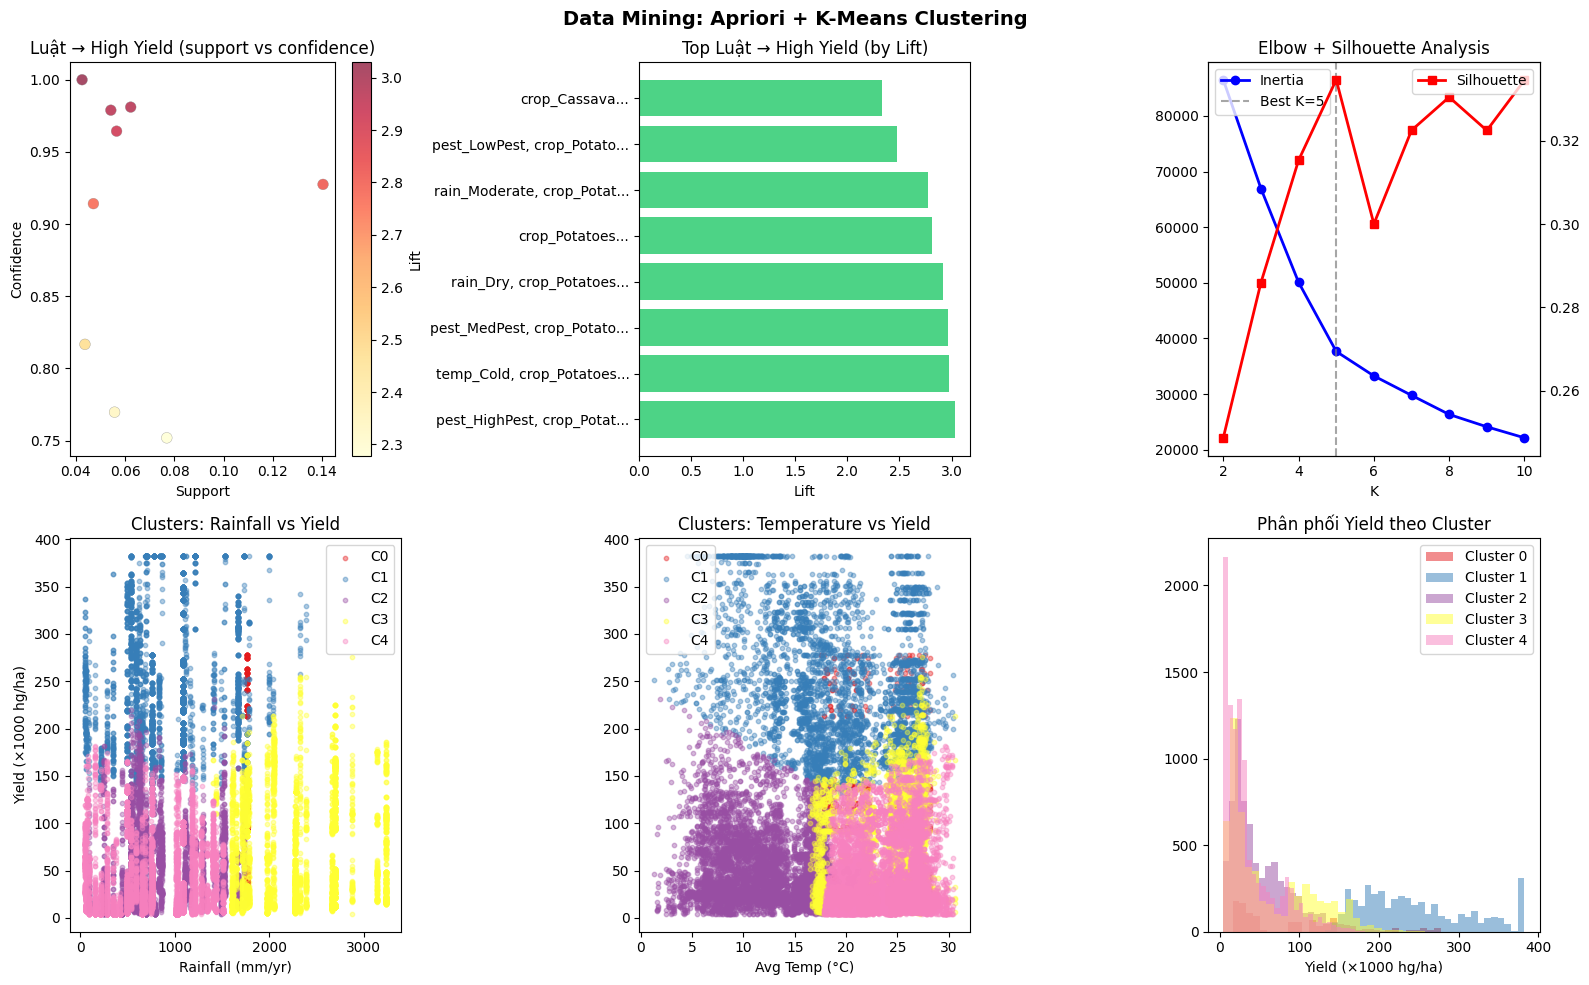

[SAVED] 05_mining.png | Rules=67 | K=5 | Sil=0.3347


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Data Mining: Apriori + K-Means Clustering", fontsize=14, fontweight="bold")

# 1. Rules: support vs confidence
if len(rules_high):
    sc = axes[0,0].scatter(rules_high["support"], rules_high["confidence"],
        c=rules_high["lift"], cmap="YlOrRd", s=60, alpha=0.7, edgecolors="gray", linewidths=0.3)
    plt.colorbar(sc, ax=axes[0,0], label="Lift")
axes[0,0].set_title("Luật → High Yield (support vs confidence)"); axes[0,0].set_xlabel("Support"); axes[0,0].set_ylabel("Confidence")

# 2. Top rules by lift
top8 = rules_high.head(8)
if len(top8):
    labs = [", ".join(list(r["antecedents"]))[:25]+"..." for _, r in top8.iterrows()]
    axes[0,1].barh(labs, top8["lift"].values, color="#2ecc71", alpha=0.85)
axes[0,1].set_title("Top Luật → High Yield (by Lift)"); axes[0,1].set_xlabel("Lift")

# 3. Elbow + Silhouette
ax_twin = axes[0,2].twinx()
axes[0,2].plot(list(K_range), inertias, "b-o", label="Inertia", linewidth=2)
ax_twin.plot(list(K_range), sils, "r-s", label="Silhouette", linewidth=2)
axes[0,2].axvline(x=best_k, color="gray", linestyle="--", alpha=0.7, label=f"Best K={best_k}")
axes[0,2].set_title("Elbow + Silhouette Analysis"); axes[0,2].set_xlabel("K")
axes[0,2].legend(loc="upper left"); ax_twin.legend(loc="upper right")

# 4. Clusters: Rain vs Yield
colors_c = plt.cm.Set1(np.linspace(0, 0.8, best_k))
for k in range(best_k):
    sub = df[df.cluster==k]
    axes[1,0].scatter(sub["average_rain_fall_mm_per_year"], sub["hg/ha_yield"]/1000,
        c=[colors_c[k]], s=10, alpha=0.4, label=f"C{k}")
axes[1,0].set_title("Clusters: Rainfall vs Yield"); axes[1,0].legend()
axes[1,0].set_xlabel("Rainfall (mm/yr)"); axes[1,0].set_ylabel("Yield (×1000 hg/ha)")

# 5. Clusters: Temp vs Yield
for k in range(best_k):
    sub = df[df.cluster==k]
    axes[1,1].scatter(sub["avg_temp"], sub["hg/ha_yield"]/1000, c=[colors_c[k]], s=10, alpha=0.4, label=f"C{k}")
axes[1,1].set_title("Clusters: Temperature vs Yield"); axes[1,1].legend()
axes[1,1].set_xlabel("Avg Temp (°C)")

# 6. Cluster yield distributions
for k in range(best_k):
    sub = df[df.cluster==k]
    axes[1,2].hist(sub["hg/ha_yield"]/1000, bins=30, alpha=0.5, label=f"Cluster {k}", color=colors_c[k])
axes[1,2].set_title("Phân phối Yield theo Cluster"); axes[1,2].legend()
axes[1,2].set_xlabel("Yield (×1000 hg/ha)")

plt.tight_layout()
plt.savefig(OUT / "05_mining.png", dpi=100, bbox_inches="tight"); plt.show()
print(f"[SAVED] 05_mining.png | Rules={len(rules)} | K={best_k} | Sil={best_sil:.4f}")